# Import

In [1]:
from scipy.io import loadmat
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from mapd import Trial, Table, Sinq
import h5py
import glob
import numpy as np
import pickle
import plotly.express as px
import matplotlib.colors as mcolors
# import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)  # reset to defaults
mpl.rcParams['pdf.fonttype'] = 42         # embed fonts as text, not paths
mpl.rcParams['svg.fonttype'] = 'none'     # keep text editable in SVG
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 11

import seaborn as sns

import random

%load_ext autoreload
%autoreload 2

import mapd.sentinels  # load once
%aimport -mapd.sentinels

%matplotlib widget

def refresh_table_addons():
    import importlib
    import mapd.table_plotters as tps
    import mapd.table_scalars as tbs
    importlib.reload(tps)
    importlib.reload(tbs)

    for name in dir(tps):
        if name.startswith('_'):
            continue
        attr = getattr(tps, name)
        setattr(Table, name[len("plot_"):], attr)
    
    for name in dir(tbs):
        if name.startswith('_'):
            continue
        if name.startswith('compute_'):
            attr = getattr(tbs, name)
            setattr(Table, name[len("compute_"):], attr)

# Load Figure 3 sinq with norpA flies

In [2]:
sinq = Sinq(sinqname='Figure3')
print(sinq.__repr__())
# sinq.df

# sinq1 = Sinq(sinqname='Figure1')
# sinq.df.loc[sinq1.df.index] = sinq1.df
# sinq.save()
# sinq.df

Found data directory: D:\Data
Sinq(Figure3, 53 rows x 29 params): 0 empties; ['210302_F1_C2', '210331_F2_C1', '210405_F1_C1', '210604_F1_C1', '210903_F3_C1', '210915_F1_C1', '210917_F2_C1', '241205_F2_C1', '241205_F3_C1', '241219_F1_C1', '241219_F2_C1', '241220_F1_C1', '241220_F2_C1', '250127_F1_C1', '250127_F2_C1', '250128_F1_C1', '250204_F1_C1', '250204_F2_C1', '250211_F2_C1', '250211_F3_C1', '250226_F2_C1', '250227_F2_C1', '250227_F3_C1', '250228_F1_C1', '250228_F2_C1', '250304_F2_C1', '250304_F3_C1', '250317_F1_C1', '250317_F2_C1', '250318_F1_C1', '250318_F2_C1', '250318_F3_C1', '250320_F1_C1', '250320_F2_C1', '250325_F1_C1', '250423_F1_C1', '250423_F2_C1', '250425_F1_C1', '250506_F2_C1', '250507_F1_C1', '250507_F2_C1', '250509_F1_C1', '250509_F2_C1', '250514_F1_C1', '250515_F1_C1', '250813_F1_C1', '250813_F3_C1', '250923_F1_C1', '250923_F2_C1', '250924_F1_C1', '250924_F2_C1', '250925_F1_C1', '250925_F2_C1'] x ['parquet', 'Table', 'genotype', 'duration', 'rms_velocity', 'outcome_fr

# Look at how long it takes for norpa flies to move

In [3]:
print([i for i in sinq.df['genotype'].unique()])
op_df = sinq.df.copy()   # Don't mess with sinq

geno_map = {'Hot-Cell-Gal4 (test)': 'HC',
 'Hot-Cell-LexA_Chr;81A06_pJFRC7':  'HC',
 'Hot-Cell-LexA_Chr;35c09_pJFRC7':  'HC',
 'Hot-Cell-LexA_Chr;35C09_pJFRC7':  'HC',
 'Hot-Cell-LexA_Chr;78E05_pJFRC7':  'HC',
 'Hot-Cell-LexA_Chr;31H05_pJFRC7':  'HC',
 'iav_Kir2_1':                      'w;iav>kir2.1',
 '31H05_pJFRC7':                    'w',
 'SS61350_pJFRC7':                  '+',
 'iav-Gal4_+;+;UAS-Kir2_1':         '+;iav>kir2.1',
 '+;iav-Gal4_UAS-Kir2_1':           '+;iav>kir2.1',
 '+;31H05-Gal4_pJFRC7':             '+',
 '+;TH-Gal4_UAS-Kir2_1':            '+;TH>kir2.1',
 '+;TH-Gal4_pJFRC7':                '+',
 'w, NorpA':                        'w,NorpA',
 '+;pJFRC7;31H05-Gal4':             '+',
 '+;pJFRC7;SS61350':              '+',
 }

op_df['geno_smpl'] = sinq.df['genotype'].map(geno_map)


learner_types = ['+', 'HC','+;TH-Gal4_pJFRC7']
non_learner_types = ['w','w;iav>kir2.1','w,NorpA','+;iav>kir2.1']
maybe_learner_types = ['+;TH>kir2.1',]
op_df['learn_geno'] = op_df['geno_smpl'].apply(
    lambda x: any(t == x for t in learner_types)
)
op_df['is_learn'] = op_df['learn_geno']
op_df['learn_note'] = ''
op_df['learn_class'] = op_df['is_learn'].astype(int)

['Hot-Cell-Gal4 (test)', 'Hot-Cell-LexA_Chr;81A06_pJFRC7', 'Hot-Cell-LexA_Chr;35c09_pJFRC7', 'Hot-Cell-LexA_Chr;35C09_pJFRC7', 'Hot-Cell-LexA_Chr;78E05_pJFRC7', 'Hot-Cell-LexA_Chr;31H05_pJFRC7', 'iav_Kir2_1', '31H05_pJFRC7', 'SS61350_pJFRC7', 'iav-Gal4_+;+;UAS-Kir2_1', '+;iav-Gal4_UAS-Kir2_1', '+;31H05-Gal4_pJFRC7', '+;TH-Gal4_UAS-Kir2_1', '+;TH-Gal4_pJFRC7', 'w, NorpA', '+;pJFRC7;31H05-Gal4', '+;pJFRC7;SS61350']


In [4]:
all(op_df['is_learn'] == op_df['learn_geno'])

True

In [5]:
sinq.df.loc[sinq.df['genotype']=='w, NorpA']

,parquet,Table,genotype,duration,rms_velocity,outcome_fractions_no_as_no_mv,outcome_fractions_as_off,outcome_fractions_rest,outcome_fractions_no_as_mv,outcome_fractions_probe,...,num_trials,blue_fraction,blue_toggle_fraction,most_common_fiberLED,lo_target_off_state,hi_target_off_state,probe_positive_effort,successes,hard_successes,holding_cost
250813_F1_C1,LEDFlashTriggerPiezoControl_250813_F1_C1_Table...,None,"w, NorpA",8825.12850,153333.610935,0.269341,0.133238,0.124642,0.110315,0.018625,...,698.0,1.0,1.0,epi_only,0.516409,0.166720,4.897259e+06,52.0,18.0,1.316828e+07
250813_F3_C1,LEDFlashTriggerPiezoControl_250813_F3_C1_Table...,None,"w, NorpA",9570.74166,227369.999273,0.143038,0.221519,0.140506,0.111392,0.025316,...,790.0,1.0,1.0,epi_only,0.349751,0.133878,1.125018e+07,82.0,20.0,2.228913e+07


# Fold blocks and average outcomes across blocks

In [81]:
op_df.loc[op_df['geno_smpl']=='w']

,parquet,Table,genotype,duration,rms_velocity,outcome_fractions_no_as_no_mv,outcome_fractions_as_off,outcome_fractions_rest,outcome_fractions_no_as_mv,outcome_fractions_probe,...,is_learn,learn_note,learn_class,success_rate,hard_success_rate,as_off_over_successes,as_off_over_hard_successes,rms_velocity_bar,holding_cost_bar,probe_positive_effort_bar
250127_F1_C1,LEDFlashTriggerPiezoControl_250127_F1_C1_Table...,None,31H05_pJFRC7,6800.32020,359639.422205,0.027510,0.707015,0.154058,0.049519,0.000000,...,False,,0,0.057772,0.004127,0.063046,0.677741,52.885660,1037.753784,1303.955583
250127_F2_C1,LEDFlashTriggerPiezoControl_250127_F2_C1_Table...,None,31H05_pJFRC7,5484.01952,374240.377294,0.033670,0.680135,0.146465,0.069024,0.000000,...,False,,0,0.057239,0.003367,0.074468,0.868794,68.241985,1296.407298,2210.302201
250128_F1_C1,LEDFlashTriggerPiezoControl_250128_F1_C1_Table...,None,31H05_pJFRC7,6574.20504,510877.041953,0.098901,0.649725,0.153846,0.083791,0.000000,...,False,,0,0.074176,0.010989,0.048634,0.297207,77.709326,3176.745083,3564.292310
250204_F1_C1,LEDFlashTriggerPiezoControl_250204_F1_C1_Table...,None,31H05_pJFRC7,7588.12330,386083.667589,0.112965,0.541720,0.138639,0.134788,0.005135,...,False,,0,0.128370,0.019255,0.025993,0.164082,50.879994,2419.817026,2445.473597
250204_F2_C1,LEDFlashTriggerPiezoControl_250204_F2_C1_Table...,None,31H05_pJFRC7,6167.51242,272029.969621,0.074875,0.610649,0.109817,0.094842,0.006656,...,False,,0,0.058236,0.008319,0.071241,0.427444,44.106919,1923.011822,1395.677506
250211_F2_C1,LEDFlashTriggerPiezoControl_250211_F2_C1_Table...,None,31H05_pJFRC7,5751.68406,197538.099630,0.081673,0.426295,0.103586,0.045817,0.001992,...,False,,0,0.053785,0.017928,0.083229,0.233041,34.344393,1901.009235,1471.952815
250211_F3_C1,LEDFlashTriggerPiezoControl_250211_F3_C1_Table...,None,31H05_pJFRC7,7776.88952,182631.274255,0.061931,0.357013,0.131148,0.038251,0.001821,...,False,,0,0.020036,0.007286,0.191021,0.458451,23.483846,375.975382,660.635429


./Figure3/folded_blocks/250211_F3_C1/exports/folded_outcome_counts_250211_F3_C1.pkl
./Figure3/folded_blocks/250211_F2_C1/exports/folded_outcome_counts_250211_F2_C1.pkl
./Figure3/folded_blocks/250204_F2_C1/exports/folded_outcome_counts_250204_F2_C1.pkl
./Figure3/folded_blocks/250204_F1_C1/exports/folded_outcome_counts_250204_F1_C1.pkl
./Figure3/folded_blocks/250128_F1_C1/exports/folded_outcome_counts_250128_F1_C1.pkl
./Figure3/folded_blocks/250127_F2_C1/exports/folded_outcome_counts_250127_F2_C1.pkl
./Figure3/folded_blocks/250127_F1_C1/exports/folded_outcome_counts_250127_F1_C1.pkl


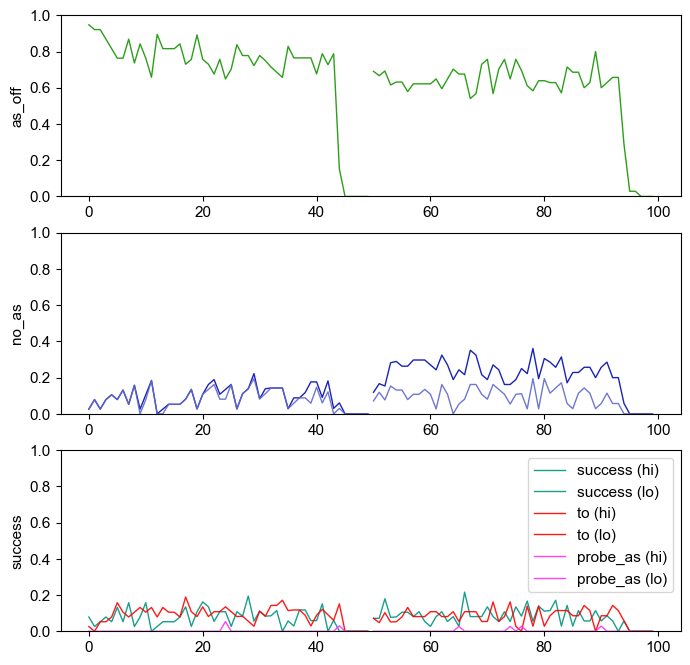

./Figure3/folded_blocks/250423_F2_C1/exports/folded_outcome_counts_250423_F2_C1.pkl
./Figure3/folded_blocks/250423_F1_C1/exports/folded_outcome_counts_250423_F1_C1.pkl
./Figure3/folded_blocks/250325_F1_C1/exports/folded_outcome_counts_250325_F1_C1.pkl
./Figure3/folded_blocks/250320_F2_C1/exports/folded_outcome_counts_250320_F2_C1.pkl
./Figure3/folded_blocks/250320_F1_C1/exports/folded_outcome_counts_250320_F1_C1.pkl
./Figure3/folded_blocks/250318_F3_C1/exports/folded_outcome_counts_250318_F3_C1.pkl
./Figure3/folded_blocks/250318_F2_C1/exports/folded_outcome_counts_250318_F2_C1.pkl
./Figure3/folded_blocks/250318_F1_C1/exports/folded_outcome_counts_250318_F1_C1.pkl
./Figure3/folded_blocks/250317_F2_C1/exports/folded_outcome_counts_250317_F2_C1.pkl
./Figure3/folded_blocks/250317_F1_C1/exports/folded_outcome_counts_250317_F1_C1.pkl


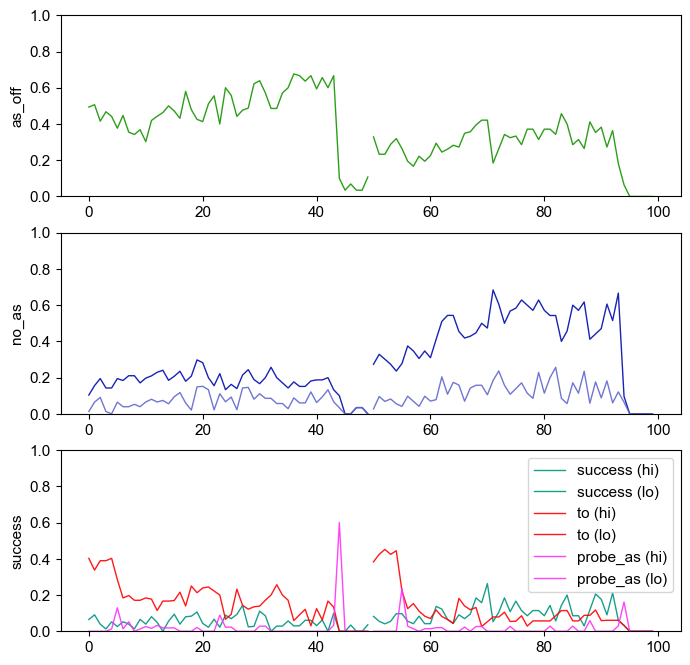

./Figure3/folded_blocks/241220_F2_C1/exports/folded_outcome_counts_241220_F2_C1.pkl
./Figure3/folded_blocks/241220_F1_C1/exports/folded_outcome_counts_241220_F1_C1.pkl
./Figure3/folded_blocks/241219_F2_C1/exports/folded_outcome_counts_241219_F2_C1.pkl
./Figure3/folded_blocks/241219_F1_C1/exports/folded_outcome_counts_241219_F1_C1.pkl
./Figure3/folded_blocks/241205_F3_C1/exports/folded_outcome_counts_241205_F3_C1.pkl
./Figure3/folded_blocks/241205_F2_C1/exports/folded_outcome_counts_241205_F2_C1.pkl


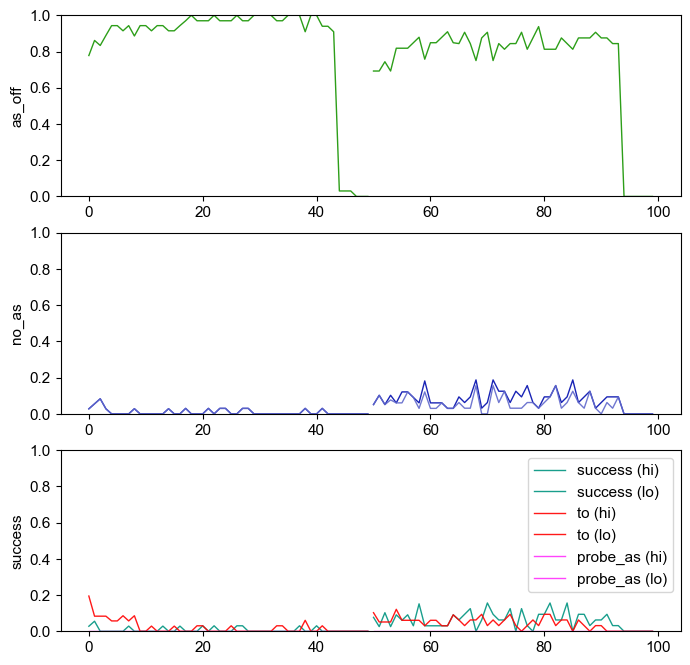

./Figure3/folded_blocks/250514_F1_C1/exports/folded_outcome_counts_250514_F1_C1.pkl
./Figure3/folded_blocks/250509_F2_C1/exports/folded_outcome_counts_250509_F2_C1.pkl
./Figure3/folded_blocks/250509_F1_C1/exports/folded_outcome_counts_250509_F1_C1.pkl
./Figure3/folded_blocks/250507_F2_C1/exports/folded_outcome_counts_250507_F2_C1.pkl
./Figure3/folded_blocks/250507_F1_C1/exports/folded_outcome_counts_250507_F1_C1.pkl
./Figure3/folded_blocks/250506_F2_C1/exports/folded_outcome_counts_250506_F2_C1.pkl


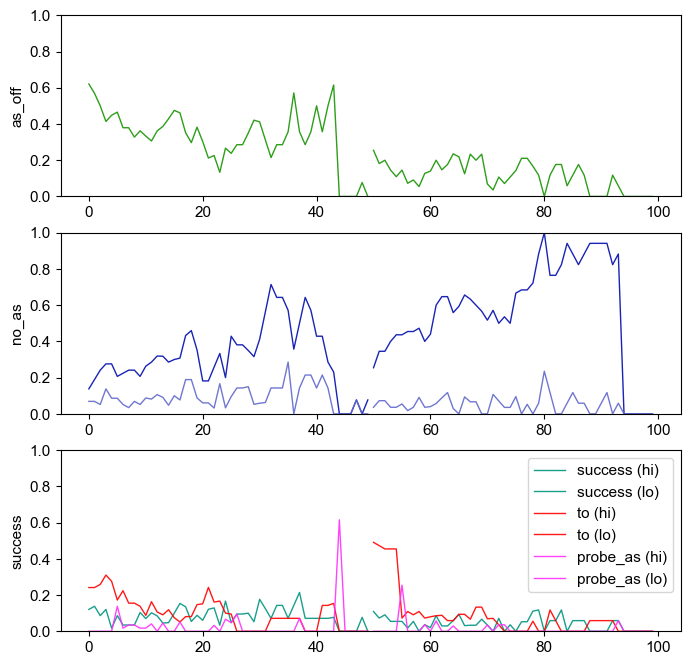

In [101]:
from collections import defaultdict

for g in ['w','+;iav>kir2.1','w;iav>kir2.1','+;TH>kir2.1']:

    norm = True
    total_outcomes = None
    total_success = None
    total_probe = None
    outcome_dict = defaultdict(dict)

    g_flies =    op_df.loc[op_df['geno_smpl']==g]
    for dfc in reversed(g_flies.index):
        export_path = f'./Figure3/folded_blocks/{dfc}/exports'
        pklpat = f'{export_path}/folded_outcome_counts_{dfc}.pkl'
        file_path = glob.glob(pklpat)
        if file_path:
            file_path = file_path[0]
            print(file_path)

        outcome_dict[dfc] = pd.read_pickle(file_path)

        if total_outcomes is None:
            total_outcomes = outcome_dict[dfc].copy()
        else:
            total_outcomes = total_outcomes.add(outcome_dict[dfc], fill_value=0)

    plt.close('all')
    fig = Figure(figsize=(8,8))
    lines = defaultdict(dict)

    colors = {'hi': '#1f77b4', 
            'lo': '#d62728'}
    colors = {'as_off': "#169400", 
                'no_as': "#000cad",
                'no_as_mv': "#6068cb",
                'success': "#009480",
                'to': "#FF0000",
                'probe_as': "#FF30FC",
            }

    hi_x = total_outcomes.xs('hi', level='pyasState').index
    x = {'hi': hi_x,
        'lo': total_outcomes.xs('lo', level='pyasState').index + hi_x[-1] + 1}

    outcome_to_ax = {'as_off':1,
                    'no_as':2,
                    'no_as_mv':2,
                    'success':3,
                    'to':3,
                    'probe_as':3,}

    ax_ids = sorted(set(outcome_to_ax.values()))
    ax_id_to_ax = {}
    for i, ax_id in enumerate(ax_ids, start=1):
        ax_id_to_ax[ax_id] = fig.add_subplot(len(ax_ids), 1, i)

    # for dfc in reversed(sinq2.df.index):
    for dfc in outcome_dict.keys():
        for outcome in outcome_to_ax.keys():
            for st in ['hi','lo']:
                outcomes = outcome_dict[dfc]
                ax = ax_id_to_ax[outcome_to_ax[outcome]]
                hi_y = outcomes.xs(st, level='pyasState').get(outcome)
                if norm:
                    hi_y = hi_y / outcomes.xs(st, level='pyasState').get('max_cnts')

                # ax.scatter(
                #             x[st], hi_y, marker='.',s=5, alpha=0.9, c=colors[outcome]
                #         )
                if norm:
                    ax.set_ylim([0, 1])
                else:
                    ax.set_ylim([0, np.max(outcomes.xs(st, level='pyasState').get('max_cnts'))])


    for outcome in outcome_to_ax.keys():
        for st in ['hi','lo']:
            ax = ax_id_to_ax[outcome_to_ax[outcome]]
            hi_y = total_outcomes.xs(st, level='pyasState').get(outcome)
            if norm:
                hi_y = hi_y / total_outcomes.xs(st, level='pyasState').get('max_cnts')

            lines[outcome][st], = ax.plot(
                        x[st], hi_y, label=f'{outcome} ({st})', linewidth=1, alpha=0.9, color=colors[outcome]
                    )
            if norm:
                ax.set_ylim([0, 1])
            else:
                ax.set_ylim([0, np.max(total_outcomes.xs(st, level='pyasState').get('max_cnts'))])

    ax_id_to_ax[1].set_ylabel('as_off')
    ax_id_to_ax[2].set_ylabel('no_as')
    ax_id_to_ax[3].set_ylabel('success')
    ax_id_to_ax[3].legend()
    fig.savefig(f'./Figure3/outcomes_over_blocks_{_get_gstr(g)}.svg',format='svg')
    display(fig)

In [103]:
pd.Index([i for i in range(500)])

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       490, 491, 492, 493, 494, 495, 496, 497, 498, 499],
      dtype='int64', length=500)

In [115]:
# index=
T.df.loc[T.df.index[50:450]]

,timestamp,background,cueDelayDurInSec,cueRampDurInSec,cueStimDurInSec,displacement,displacements,durSweep,gain,mode,...,fiberLED,filtercube_status,op_cnd_blocks,total_duration,is_rest,is_probe,as_duration,probe_min,probe_max,probe_zero
trial_number,,,,,,,,,,,,,,,,,,,,,
51,2025-05-06 15:04:02.177996,5.0,0.5,0.07,0.3,-0.5,"[-1.0, -0.5, 0.5, 1.0]",6.5,NaN,None,...,epi_only,green,3,9.20134,False,False,0.86364,-355.997086,-42.011261,600.0
52,2025-05-06 15:04:11.489996,5.0,0.5,0.07,0.3,-1.0,"[-1.0, -0.5, 0.5, 1.0]",6.5,NaN,None,...,epi_only,green,3,10.24622,False,False,0.45630,-375.679779,-26.390076,600.0
53,2025-05-06 15:04:21.637999,5.0,0.5,0.07,0.3,0.5,"[-1.0, -0.5, 0.5, 1.0]",6.5,NaN,None,...,epi_only,green,3,8.93738,False,False,1.29706,-366.619492,-21.703720,600.0
54,2025-05-06 15:04:30.569001,5.0,0.5,0.07,0.3,1.0,"[-1.0, -0.5, 0.5, 1.0]",6.5,NaN,None,...,epi_only,green,3,7.44308,False,False,0.82362,-313.507462,-13.893127,600.0
55,2025-05-06 15:04:38.021003,5.0,0.5,0.07,0.3,-0.5,"[-1.0, -0.5, 0.5, 1.0]",6.5,NaN,None,...,epi_only,green,3,8.07602,False,False,0.00000,-281.952667,-266.643906,600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,2025-05-06 16:08:17.817997,5.0,0.5,0.07,0.3,-0.5,"[-1.0, -0.5, 0.5, 1.0]",6.5,NaN,None,...,epi_only,green,16,9.62172,False,False,0.00000,-170.104980,-168.855286,600.0
447,2025-05-06 16:08:27.443995,5.0,0.5,0.07,0.3,0.5,"[-1.0, -0.5, 0.5, 1.0]",6.5,NaN,None,...,epi_only,green,16,7.40508,False,False,0.00000,-169.480133,-168.542862,600.0
448,2025-05-06 16:08:34.830004,5.0,0.5,0.07,0.3,1.0,"[-1.0, -0.5, 0.5, 1.0]",6.5,NaN,None,...,epi_only,green,16,8.37096,False,False,0.00000,-169.480133,-167.918015,600.0


In [119]:
sinq.drop_tables()

In [118]:
for g in ['w','+;iav>kir2.1','+;TH>kir2.1']:
    g_flies =    op_df.loc[op_df['geno_smpl']==g]
    for dfc in reversed(g_flies.index):
        T = sinq.restore_table(dfc)
        T.extract_trial_properties()
        T.fig_folder = f'./Figure3/heatmaps/{_get_gstr(g)}'
        idx=T.df.loc[T.df.index[50:450]].index
        print(f'{dfc}: making heat map for {len(idx)} trials')
        try:
            fig,ax,df = T.plot_probe_position_heatmap(index=idx,cmin=-500,cmax=10,format='svg')
        except Exception as e:
            print(f'{e}')

Table 250211_F3_C1 in sinq
250211_F3_C1: making heat map for 400 trials
Table 250211_F2_C1 in sinq
250211_F2_C1: making heat map for 400 trials
Table 250204_F2_C1 in sinq
250204_F2_C1: making heat map for 400 trials
Table 250204_F1_C1 in sinq
250204_F1_C1: making heat map for 400 trials
Table 250128_F1_C1 in sinq
250128_F1_C1: making heat map for 400 trials
Table 250127_F2_C1 in sinq
250127_F2_C1: making heat map for 400 trials
Table 250127_F1_C1 in sinq
250127_F1_C1: making heat map for 400 trials
Table 250423_F2_C1 in sinq
250423_F2_C1: making heat map for 400 trials
Table 250423_F1_C1 in sinq
250423_F1_C1: making heat map for 144 trials
Table 250325_F1_C1 in sinq
250325_F1_C1: making heat map for 400 trials
Table 250320_F2_C1 in sinq
250320_F2_C1: making heat map for 400 trials
Table 250320_F1_C1 in sinq
250320_F1_C1: making heat map for 400 trials
Table 250318_F3_C1 in sinq
250318_F3_C1: making heat map for 400 trials
Table 250318_F2_C1 in sinq
250318_F2_C1: making heat map for 213